In [101]:
import sys 
import xarray as xr
import numpy as np
import os
import pandas as pd
import yaml
from numpy import random
import math
from datetime import datetime, timedelta
from parcels import FieldSet, Field, VectorField, ParticleSet, JITParticle, ParcelsRandom, Variable
from glob import glob

import matplotlib.pyplot as plt

from parcels import ScipyParticle, AdvectionRK4,AdvectionRK4_3D


In [102]:
sys.path.append(os.getcwd()+'/Source_vvl')

from OP_Kernels import *
from OP_functions import *

In [103]:
lat = np.ones(1)*49.35844243668596
lon = np.ones(1)*-123.80204117521916
z = np.ones(1)*280

In [104]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')

def finder(jjii,lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

finder(jjii,49.35844243668596,-123.80204117521916)

(512, 251)

In [105]:
def load_config(config_yaml):
   with open(config_yaml) as f:
       config = yaml.safe_load(f)
   return config

In [106]:
param = load_config('yaml/config.yaml')
start = datetime(param['startdate']['year'], param['startdate']['month'], param['startdate']['day']) #Start date
length = 1#param['param']['length'] # Set Time length [days] 
dt = param['param']['dt'] #toggle between - or + to pick backwards or forwards 
N = param['param']['N'] # Name of deploy loc file
dd = param['param']['dd'] #max depth difference z in N
name = param['file']['name'] #name output file
dtp = param['param']['dtp'] #how often particle released in hours
odt = param['param']['odt'] #how often data is recorded
rrr = param['param']['r'] #radious of particle deployment
SI = param['param']['SI'] #how many particles per super-individual

length = 1
duration = timedelta(days=length)
print(f"The model will run for {duration.days} days, starting at {start}")

lon, lat, z = pandas_deploy(N,SI,rrr,dd,dtp)

N = len(lat)
print(f"The model will release {N} particle every timestep")

daterange = [start+timedelta(days=i) for i in range(length)]
fn =  name + '.zarr'
outfile = os.path.join(os.getcwd()+'/results/', fn)

print(f"Output file: {outfile}")

The model will run for 1 days, starting at 2007-04-01 00:00:00
The model will release 3396 particle every timestep
Output file: /ocean/jvalenti/MOAD/analysis-jose/notebooks/MP_model/results/test_reseed.zarr


In [107]:
duration = timedelta(days=length)
paths = path('salish')
cgrid_dim = {'lon': 'glamf','lat': 'gphif','depth':'not_yet_set', 'time':'time_counter'}
Ulist, Vlist, Wlist, Tlist = [], [], [], []

for day in range(duration.days):
  path_NEMO = make_prefix(start + timedelta(days=day),paths['NEMO'])
  Ulist.append(path_NEMO + '_grid_U.nc')
  Vlist.append(path_NEMO + '_grid_V.nc')
  Wlist.append(path_NEMO + '_grid_W.nc')
  Tlist.append(path_NEMO + '_grid_T.nc')

filenames = {
  'U': {'lon': paths['coords'],'lat': paths['coords'],'depth': Ulist[0],'data': Ulist},
  'V': {'lon': paths['coords'],'lat': paths['coords'],'depth': Vlist[0],'data': Vlist},
  'W': {'lon': paths['coords'],'lat': paths['coords'],'depth': Wlist[0],'data': Wlist}
}
dimensions = {
  'U': {'lon': 'glamf','lat': 'gphif','depth':'not_yet_set', 'time':'time_counter'},
  'V': {'lon': 'glamf','lat': 'gphif','depth':'not_yet_set', 'time':'time_counter'},
  'W': {'lon': 'glamf','lat': 'gphif','depth':'not_yet_set', 'time':'time_counter'},
}
variables = {
  'U': 'vozocrtx',
  'V': 'vomecrty',
  'W': 'vovecrtz'
}

# field_set = FieldSet.from_c_grid_dataset(
#     filenames,
#     variables,
#     dimensions,
#     mesh="flat",
#     allow_time_extrapolation=True,
# )

In [108]:
mask_ds = xr.open_dataset(paths['mask'], decode_times=False).isel(t=0)
TD = np.asarray(mask_ds.totaldepth)
depthw_0 = np.asarray(xr.open_dataset(Wlist[0]).depthw)
depthu_0 = np.asarray(xr.open_dataset(Ulist[0]).depthu)

stretch_w = np.asarray(depthw_0[:,None,None] / TD, dtype=np.float32)
stretch_u = np.asarray(depthu_0[:,None,None] / TD, dtype=np.float32)

/tmp/ipykernel_2252880/3706030301.py:6: RuntimeWarning: divide by zero encountered in divide
  stretch_w = np.asarray(depthw_0[:,None,None] / TD, dtype=np.float32)
/tmp/ipykernel_2252880/3706030301.py:6: RuntimeWarning: invalid value encountered in divide
  stretch_w = np.asarray(depthw_0[:,None,None] / TD, dtype=np.float32)
/tmp/ipykernel_2252880/3706030301.py:7: RuntimeWarning: divide by zero encountered in divide
  stretch_u = np.asarray(depthu_0[:,None,None] / TD, dtype=np.float32)


In [109]:
depthw_list = []
for day in range(duration.days):
    depthw_file = f'test_depthw_{day}.nc'
    
    ds_t = xr.open_dataset(Tlist[day], decode_times=False)
    ds_w = xr.open_dataset(Wlist[day], decode_times=False)
    ds_u = xr.open_dataset(Ulist[day], decode_times=False)

    e3t = ds_t['e3t']
    ws = ds_w['vovecrtz']
    eta = np.asarray(ds_t['sossheig'].fillna(0.0))   
    depthw = np.asarray(depthw_0[None, :, None, None]+ eta[:, None, :, :] * stretch_w[None, :, :, :]).astype("float32")
    #depthu = np.asarray(depthu_0[None, :, None, None]+ eta[:, None, :, :] * stretch_u[None, :, :, :]).astype("float32")

    #depthw[np.isnan(depthw)] = 0
    #depthu = xr.DataArray(depthu, dims=e3t.dims, coords=e3t.coords, name='depthu')
    depthw = xr.DataArray(depthw, dims=ws.dims, coords=ws.coords, name='depthw')

    depth_T = xr.Dataset({"depthw": depthw}) #"depthu": depthu,
    #depth_T.to_netcdf(depthw_file)
    depthw_list.append(depthw_file)
    ds_t.close()

/tmp/ipykernel_2252880/476221416.py:12: RuntimeWarning: invalid value encountered in multiply
  depthw = np.asarray(depthw_0[None, :, None, None]+ eta[:, None, :, :] * stretch_w[None, :, :, :]).astype("float32")


In [110]:
field_set = FieldSet.from_netcdf(
    filenames,
    variables,
    dimensions,
    mesh="spherical",
    allow_time_extrapolation=True,
    interp_method='cgrid_velocity',
    gridindexingtype='nemo',
)

filenames['depthw'] = {
    'lon': paths['coords'],
    'lat': paths['coords'],
    'depth': depthw_list[0],  
    'data': depthw_list,
}
variables['depthw'] = 'depthw'
dimensions['depthw'] =  {'lon': 'glamf','lat': 'gphif','depth':'not_yet_set', 'time':'time_counter'} 

field_depthw = Field.from_netcdf(
    filenames['depthw'],
    variables['depthw'],
    dimensions['depthw'],
    mesh="spherical",
    allow_time_extrapolation=True,
    interp_method='cgrid_tracer',
    gridindexingtype='nemo',
)

field_set.add_field(field_depthw)

filenames['depthu'] = {
    'lon': paths['coords'],
    'lat': paths['coords'],
    'depth': depthw_list,  
    'data': depthw_list,
}
# variables['depthu'] = 'depthu'
# dimensions['depthu'] = {'lon': 'glamu','lat': 'gphiu','depth':'not_yet_set', 'time':'time_counter'}   

# field_depthu = Field.from_netcdf(
#     filenames['depthu'],
#     variables['depthu'],
#     dimensions['depthu'],
#     mesh="spherical",
#     allow_time_extrapolation=True,
#     interp_method='cgrid_tracer',
#     gridindexingtype='nemo',
# )

# field_set.add_field(field_depthu)

field_set.U.set_depth_from_field(field_set.depthw)
field_set.V.set_depth_from_field(field_set.depthw)
field_set.W.set_depth_from_field(field_set.depthw)

/ocean/jvalenti/MOAD/analysis-jose/.pixi/envs/parcels/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /ocean/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might be wrongly parsed.
  with _grid_fb_class(
/ocean/jvalenti/MOAD/analysis-jose/.pixi/envs/parcels/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /ocean/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might be wrongly parsed.
  with _grid_fb_class(
/ocean/jvalenti/MOAD/analysis-jose/.pixi/envs/parcels/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /ocean/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might b

In [111]:
# filenames = {
#   'e3t': {'lon': paths['coords'],'lat': paths['coords'],'depth': Tlist[0],'data': Tlist},
# }
# dimensions = {
#   'e3t': cgrid_dim,
# }
# variables = {
#   'e3t': 'e3t'
# }

# dimensions["e3t"] = {
#     "lon": "glamf",
#     "lat": "gphif",
#     "depth": "deptht",
#     "time": "time_counter",
# }


In [112]:
# filenames= {
#     'K_z': {'lon': paths['coords'], 'lat': paths['coords'], 'depth': Wlist[0], 'data': Wlist},
#     'T': {'lon': paths['coords'], 'lat': paths['coords'], 'depth': Wlist[0], 'data': Tlist},
#     'S': {'lon': paths['coords'], 'lat': paths['coords'], 'depth': Wlist[0], 'data': Tlist},
#     'ssh': {'lon': paths['coords'], 'lat': paths['coords'], 'data': Tlist},
#     'R': {'lon': paths['coords'], 'lat': paths['coords'], 'depth': Wlist[0], 'data': Tlist},
#     'totaldepth' : {'lon': paths['coords'], 'lat': paths['coords'], 'data': paths['mask']}
# }

# dimensions = {
#     'K_z': {'lon': 'glamt', 'lat': 'gphit', 'depth': 'depthw','time': 'time_counter'},
#     'T': {'lon': 'glamt', 'lat': 'gphit', 'depth': 'depthw','time': 'time_counter'},
#     'S': {'lon': 'glamt', 'lat': 'gphit', 'depth': 'depthw','time': 'time_counter'},
#     'ssh': {'lon': 'glamt', 'lat': 'gphit','time': 'time_counter'},
#     'R': {'lon': 'glamt', 'lat': 'gphit', 'depth': 'depthw','time': 'time_counter'},
#     'totaldepth' : {'lon': 'glamt', 'lat': 'gphit'}
# }

# variables = {'K_z':'vert_eddy_diff', 'T':'votemper','S':'vosaline','R':'sigma_theta','ssh':'sossheig','totaldepth':'totaldepth'}

# field_set_2 = FieldSet.from_netcdf(
#     filenames,
#     variables,
#     dimensions,
#     mesh="flat",
#     allow_time_extrapolation=True,
#     gridindexingtype="nemo",
# )
# field_set.add_field(field_set_2.K_z)
# field_set.add_field(field_set_2.T)
# field_set.add_field(field_set_2.R)

In [113]:
#Define our Parcels Particles
class MPParticle(JITParticle):    
    fact = Variable('fact', initial = 1)


In [114]:
duration = timedelta(days=length)
paths = path('salish')
cgrid_dim = {'lon': 'glamf','lat': 'gphif','depth':'depthw', 'time':'time_counter'}
Ulist, Vlist, Wlist, Tlist = [], [], [], []

for day in range(duration.days):
  path_NEMO = make_prefix(start + timedelta(days=day),paths['NEMO'])
  Ulist.append(path_NEMO + '_grid_U.nc')
  Vlist.append(path_NEMO + '_grid_V.nc')
  Wlist.append(path_NEMO + '_grid_W.nc')
  Tlist.append(path_NEMO + '_grid_T.nc')

filenames = {
  'U': {'lon': paths['coords'],'lat': paths['coords'],'depth': Wlist[0],'data': Ulist},
  'V': {'lon': paths['coords'],'lat': paths['coords'],'depth': Wlist[0],'data': Vlist},
  'W': {'lon': paths['coords'],'lat': paths['coords'],'depth': Wlist[0],'data': Wlist}
}
dimensions = {
  'U': {'lon': 'glamf','lat': 'gphif','depth':'depthw', 'time':'time_counter'},
  'V': {'lon': 'glamf','lat': 'gphif','depth':'depthw', 'time':'time_counter'},
  'W': {'lon': 'glamf','lat': 'gphif','depth':'depthw', 'time':'time_counter'},
}
variables = {
  'U': 'vozocrtx',
  'V': 'vomecrty',
  'W': 'vovecrtz'
}

fieldset_2 = FieldSet.from_nemo(
    filenames,
    variables,
    dimensions,
    allow_time_extrapolation=True,
)

filenames['totaldepth'] = {'lon': paths['coords'], 'lat': paths['coords'], 'data': paths['mask']}
filenames['ssh'] = {'lon': paths['coords'], 'lat': paths['coords'], 'data': Tlist}
variables['totaldepth']= 'totaldepth'
variables['ssh']= 'sossheig'

#Add Bathymetry 2D field
dimensions = {'lon': 'glamt', 'lat': 'gphit'}
TD = Field.from_netcdf(filenames['totaldepth'], variables['totaldepth'], dimensions,allow_time_extrapolation=True)
fieldset_2.add_field(TD)

#Add SSH 
dimensions = {'lon': 'glamt', 'lat': 'gphit','time': 'time_counter'}
SSH = Field.from_netcdf(filenames['ssh'], variables['ssh'], dimensions,allow_time_extrapolation=True)
fieldset_2.add_field(SSH)

/ocean/jvalenti/MOAD/analysis-jose/.pixi/envs/parcels/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /ocean/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might be wrongly parsed.
  with _grid_fb_class(
/ocean/jvalenti/MOAD/analysis-jose/.pixi/envs/parcels/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /ocean/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might be wrongly parsed.
  with _grid_fb_class(
/ocean/jvalenti/MOAD/analysis-jose/.pixi/envs/parcels/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /ocean/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might b

In [168]:
lat = np.ones(1)*49.33451996322204
lon = np.ones(1)*-123.83734250024288
z = np.ones(1)*30

In [169]:
#pset = ParticleSet.from_list(field_set, ScipyParticle, lon=lon, lat=lat, depth=z)#, repeatdt = timedelta(hours=dtp))#,partition_function=nemo_partition_function)
pset = ParticleSet.from_list(field_set, ScipyParticle, lon=lon, lat=lat, depth=z, lonlatdepth_dtype=np.float32)
pset2 = ParticleSet.from_list(fieldset_2, MPParticle, lon=lon, lat=lat, depth=z, lonlatdepth_dtype=np.float32)
pset3 = ParticleSet.from_list(fieldset_2, MPParticle, lon=lon, lat=lat, depth=z, lonlatdepth_dtype=np.float32)
pset4 = ParticleSet.from_list(fieldset_2, JITParticle, lon=lon, lat=lat, depth=z, lonlatdepth_dtype=np.float32)

In [170]:
def Advection_0(particle, fieldset, time): 
    (u1, v1, w1) = fieldset.UVW[particle]
    lon1 = particle.lon + u1 * 0.5 * particle.dt
    lat1 = particle.lat + v1 * 0.5 * particle.dt
    dep1 = particle.depth + w1 * 0.5 * particle.dt
    (u2, v2, w2) = fieldset.UVW[time + 0.5 * particle.dt, dep1, lat1, lon1, particle]
    lon2 = particle.lon + u2 * 0.5 * particle.dt
    lat2 = particle.lat + v2 * 0.5 * particle.dt
    dep2 = particle.depth + w2 * 0.5 * particle.dt
    (u3, v3, w3) = fieldset.UVW[time + 0.5 * particle.dt, dep2, lat2, lon2, particle]
    lon3 = particle.lon + u3 * particle.dt
    lat3 = particle.lat + v3 * particle.dt
    dep3 = particle.depth + w3 * particle.dt
    (u4, v4, w4) = fieldset.UVW[time + particle.dt, dep3, lat3, lon3, particle]
    particle_dlon += (u1 + 2 * u2 + 2 * u3 + u4) / 6 * particle.dt  
    particle_dlat += (v1 + 2 * v2 + 2 * v3 + v4) / 6 * particle.dt  
    particle_ddepth += (w1 + 2 * w2 + 2 * w3 + w4) / 6 * particle.dt 

In [171]:
def Advection(particle, fieldset, time): 
    (u1, v1, w1) = fieldset.UVW[particle]
    lon1 = particle.lon + u1 * 0.5 * particle.dt
    lat1 = particle.lat + v1 * 0.5 * particle.dt
    dep1 = particle.depth - w1 * 0.5 * particle.dt
    (u2, v2, w2) = fieldset.UVW[time + 0.5 * particle.dt, dep1, lat1, lon1, particle]
    lon2 = particle.lon + u2 * 0.5 * particle.dt
    lat2 = particle.lat + v2 * 0.5 * particle.dt
    dep2 = particle.depth - w2 * 0.5 * particle.dt
    (u3, v3, w3) = fieldset.UVW[time + 0.5 * particle.dt, dep2, lat2, lon2, particle]
    lon3 = particle.lon + u3 * particle.dt
    lat3 = particle.lat + v3 * particle.dt
    dep3 = particle.depth - w3 * particle.dt
    (u4, v4, w4) = fieldset.UVW[time + particle.dt, dep3, lat3, lon3, particle]
    particle_dlon += (u1 + 2 * u2 + 2 * u3 + u4) / 6 * particle.dt  
    particle_dlat += (v1 + 2 * v2 + 2 * v3 + v4) / 6 * particle.dt  
    particle_ddepth += -(w1 + 2 * w2 + 2 * w3 + w4) / 6 * particle.dt 

In [172]:
def Advection_full(particle, fieldset, time): 
    ssh = fieldset.sossheig[time, particle.depth, particle.lat, particle.lon] #SSH(t)
    sshn = fieldset.sossheig[time+particle.dt, particle.depth, particle.lat, particle.lon] #SSH(t+dt)
    td = fieldset.totaldepth[time, particle.depth, particle.lat, particle.lon]#Total_depth
    particle.fact = (1+ssh/td) #VVl conversion factor
    VVL = (sshn-ssh)*particle.depth/td #VVl w velocity correction
    #4th order RK
    (u1, v1, w1) = fieldset.UVW[particle]
    lon1 = particle.lon + u1*.5*particle.dt
    lat1 = particle.lat + v1*.5*particle.dt
    dep1 = particle.depth + w1*.5*particle.dt/particle.fact
    (u2, v2, w2) = fieldset.UVW[time + .5 * particle.dt, dep1, lat1, lon1,particle]
    lon2 = particle.lon + u2*.5*particle.dt
    lat2 = particle.lat + v2*.5*particle.dt
    dep2 = particle.depth + w2*.5*particle.dt/particle.fact
    (u3, v3, w3) = fieldset.UVW[time + .5 * particle.dt, dep2, lat2, lon2,particle]
    lon3 = particle.lon + u3*particle.dt
    lat3 = particle.lat + v3*particle.dt
    dep3 = particle.depth + w3*particle.dt/particle.fact
    (u4, v4, w4) = fieldset.UVW[time + particle.dt, dep3, lat3, lon3,particle]
    particle_dlon += (u1 + 2*u2 + 2*u3 + u4) / 6. * particle.dt
    particle_dlat += (v1 + 2*v2 + 2*v3 + v4) / 6. * particle.dt
    particle_ddepth += (w1 + 2*w2 + 2*w3 + w4) /6. * particle.dt/particle.fact + VVL
    if particle_ddepth + particle.depth < 0:
        particle_ddepth = -(2*particle.depth + particle_ddepth) #reflection on surface

In [173]:
def Advection_part(particle, fieldset, time): 
    ssh = fieldset.sossheig[time, particle.depth, particle.lat, particle.lon] #SSH(t)
    td = fieldset.totaldepth[time, particle.depth, particle.lat, particle.lon]#Total_depth
    particle.fact = (1+ssh/td) #VVl conversion factor
    (u1, v1, w1) = fieldset.UVW[particle]
    lon1 = particle.lon + u1*.5*particle.dt
    lat1 = particle.lat + v1*.5*particle.dt
    dep1 = particle.depth + w1*.5*particle.dt/particle.fact
    (u2, v2, w2) = fieldset.UVW[time + .5 * particle.dt, dep1, lat1, lon1,particle]
    lon2 = particle.lon + u2*.5*particle.dt
    lat2 = particle.lat + v2*.5*particle.dt
    dep2 = particle.depth + w2*.5*particle.dt/particle.fact
    (u3, v3, w3) = fieldset.UVW[time + .5 * particle.dt, dep2, lat2, lon2,particle]
    lon3 = particle.lon + u3*particle.dt
    lat3 = particle.lat + v3*particle.dt
    dep3 = particle.depth + w3*particle.dt/particle.fact
    (u4, v4, w4) = fieldset.UVW[time + particle.dt, dep3, lat3, lon3,particle]
    particle_dlon += (u1 + 2*u2 + 2*u3 + u4) / 6. * particle.dt
    particle_dlat += (v1 + 2*v2 + 2*v3 + v4) / 6. * particle.dt
    particle_ddepth += (w1 + 2*w2 + 2*w3 + w4) /6. * particle.dt/particle.fact
    if particle_ddepth + particle.depth < 0:
        particle_ddepth = -(2*particle.depth + particle_ddepth) #reflection on surface

In [174]:
pset.execute(
    [Advection],
    runtime=timedelta(hours=12),
    dt=timedelta(seconds=60),
    output_file=pset.ParticleFile(name='output.zarr', outputdt=timedelta(minutes=30)))

INFO: Output files are stored in output.zarr.
100%|██████████| 43200.0/43200.0 [00:50<00:00, 848.92it/s] 


In [175]:
pset2.execute(
    [Advection_full],
    runtime=timedelta(hours=12),
    dt=timedelta(seconds=60),
    output_file=pset2.ParticleFile(name='output2.zarr', outputdt=timedelta(minutes=30)))

INFO: Output files are stored in output2.zarr.
100%|██████████| 43200.0/43200.0 [00:32<00:00, 1333.27it/s]


In [176]:
# pset3.execute(
#     [Advection_part],
#     runtime=timedelta(hours=12),
#     dt=timedelta(seconds=60),
#     output_file=pset3.ParticleFile(name='output3.zarr', outputdt=timedelta(minutes=30)))

In [177]:
pset4.execute(
    [Advection_0],
    runtime=timedelta(hours=12),
    dt=timedelta(seconds=60),
    output_file=pset4.ParticleFile(name='output4.zarr', outputdt=timedelta(minutes=30)))

INFO: Output files are stored in output4.zarr.
100%|██████████| 43200.0/43200.0 [00:29<00:00, 1474.09it/s]


In [178]:
ds_out = xr.open_zarr('output.zarr')
ds_out2 = xr.open_zarr('output2.zarr')
#ds_out3 = xr.open_zarr('output3.zarr')
ds_out4 = xr.open_zarr('output4.zarr')

# display(ds_out)

# plt.pcolormesh(field_set.U.grid.lon,field_set.U.grid.lat,field_set.U.data[0,30,:,:],cmap = 'bwr')
# plt.scatter(ds_out.lon,ds_out.lat, s=2,c=ds_out.z)
# plt.xlim([-123.85,-123.75])
# plt.ylim([49.35,49.45])
# plt.colorbar()

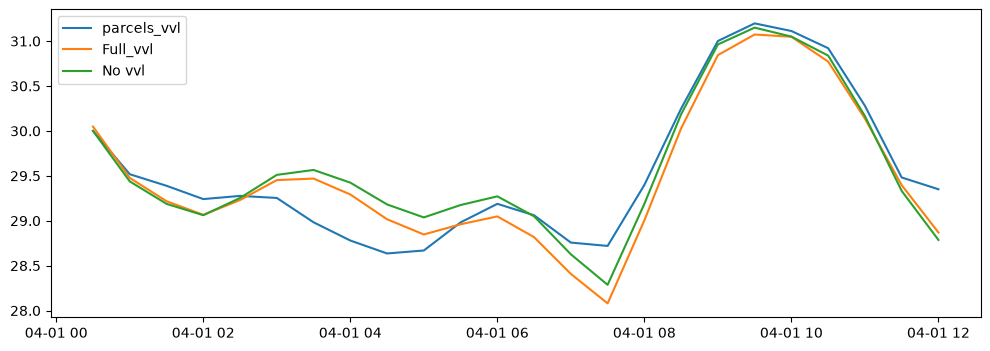

In [179]:
fig,axs = plt.subplots(1,figsize=(12,4))
plt.plot(ds_out.time.values.T,ds_out.z.values.T,label = 'parcels_vvl')
plt.plot(ds_out2.time.values.T,ds_out2.z.values.T*ds_out2.fact.values.T,label = 'Full_vvl')
#plt.plot(ds_out3.time.values.T,ds_out3.z.values.T*ds_out3.fact.values.T,label = 'Mod_vvl')
plt.plot(ds_out4.time.values.T,ds_out4.z.values.T,label = 'No vvl')
plt.legend()
#plt.ylim(285,250)

In [180]:
# pset.execute([Advection], #Buoyancy,turb_mix,Displacement,export,CheckOutOfBounds,KeepInOcean
#         runtime=duration, 
#         dt=dt,
#         output_file=pset.ParticleFile(name=outfile, outputdt=timedelta(hours=odt)))#,chunks=(int(1e5), 100)))